Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Imports

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

Set Paths

In [ ]:
# Main project folders
PROJECT_DIR = Path("/content/drive/MyDrive/Algebra_Model")
RESULTS_DIR = PROJECT_DIR / "Results"
FIGURES_DIR = PROJECT_DIR / "Figures"

# Make output folder if it does not already exist
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)
print("Results directory:", RESULTS_DIR)
print("Figures directory:", FIGURES_DIR)

Project directory: /content/drive/MyDrive/Algebra_Model
Results directory: /content/drive/MyDrive/Algebra_Model/Results
Figures directory: /content/drive/MyDrive/Algebra_Model/Figures


Define File Map

In [ ]:
file_map = {
    ("Base", "ID"): RESULTS_DIR / "base_test_results.csv",
    ("SFT", "ID"): RESULTS_DIR / "sft_test_results.csv",
    ("GRPO+SFT", "ID"): RESULTS_DIR / "grpo_test_results.csv",
    ("Base", "OOD"): RESULTS_DIR / "base_ood_test_results.csv",
    ("SFT", "OOD"): RESULTS_DIR / "sft_ood_test_results.csv",
    ("GRPO+SFT", "OOD"): RESULTS_DIR / "grpo_ood_test_results.csv",
}

for key, path in file_map.items():
    print(f"{key}: {path} | Exists: {path.exists()}")

('Base', 'ID'): /content/drive/MyDrive/Algebra_Model/Results/base_test_results.csv | Exists: True
('SFT', 'ID'): /content/drive/MyDrive/Algebra_Model/Results/sft_test_results.csv | Exists: True
('GRPO+SFT', 'ID'): /content/drive/MyDrive/Algebra_Model/Results/grpo_test_results.csv | Exists: True
('Base', 'OOD'): /content/drive/MyDrive/Algebra_Model/Results/base_ood_test_results.csv | Exists: True
('SFT', 'OOD'): /content/drive/MyDrive/Algebra_Model/Results/sft_ood_test_results.csv | Exists: True
('GRPO+SFT', 'OOD'): /content/drive/MyDrive/Algebra_Model/Results/grpo_ood_test_results.csv | Exists: True


Load All CSVs

In [ ]:
dfs = []

for (model, split), path in file_map.items():
    df = pd.read_csv(path)
    df["model"] = model
    df["split"] = split
    df["source_file"] = path.name
    dfs.append(df)

raw_df = pd.concat(dfs, ignore_index=True)
raw_df = raw_df.rename(columns={"formatted": "formatting"})

print("Combined shape:", raw_df.shape)
print("Columns found:")
print(list(raw_df.columns))
raw_df.head()

Combined shape: (1506, 12)
Columns found:
['model', 'idx', 'theorem', 'ground_truth', 'model_output', 'correct', 'formatting', 'steps', 'tokens', 'has_final', 'split', 'source_file']


,model,idx,theorem,ground_truth,model_output,correct,formatting,steps,tokens,has_final,split,source_file
0,Base,0,(2*a+5)*(3*a-4) = 6*a**2 + 7*a - 20,Step 1: Distribute 2*a -> 2*a*3*a - 8*a. Step ...,1: (2*a+5)*(3*a-4)\n2: 6*a^2 - 4*a*3*a + 5*3*a...,1,0,0,211,1,ID,base_test_results.csv
1,Base,1,(c+2)*(c+5) = c**2 + 7*c + 10,Step 1: Distribute c -> c*c + 5*c. Step 2: Dis...,1: (c+2)*(c+5)\n2: = (c+2)*(c+5)\n3: = c*(c+5)...,1,0,0,112,1,ID,base_test_results.csv
2,Base,2,(4*y-1)*(2*y-3) = 8*y**2 - 14*y + 3,Step 1: Distribute 4*y -> 4*y*2*y - 12*y. Step...,1: (4*y-1)*(2*y-3)\n2: 16*y**2 - 4*y*3 - 4*y*1...,0,0,0,216,1,ID,base_test_results.csv
3,Base,3,(b+7)**2 = b**2 + 14*b + 49,Step 1: Rewrite (b+7)**2 -> (b+7)*(b+7). Step ...,1: (b+7)**2\n2: = (b+7) * (b+7)\n3: = b*b + 2*...,1,0,0,135,1,ID,base_test_results.csv
4,Base,4,(y+16)*(y+4) = y**2 + 20*y + 64,Step 1: Distribute y -> y*y + 4*y. Step 2: Dis...,1: (y + 16) * (y + 4)\n2: y*y + y*16 + y*4 + 1...,1,0,0,121,1,ID,base_test_results.csv


Detect Metric Columns Automatically

In [ ]:
def find_column(columns, candidates):
    """
    Return the first matching column from candidates (case-insensitive),
    or None if no match is found.
    """
    lower_map = {c.lower(): c for c in columns}
    for candidate in candidates:
        if candidate.lower() in lower_map:
            return lower_map[candidate.lower()]
    return None


correctness_candidates = [
    "correctness", "correct", "is_correct", "accuracy", "answer_correct",
    "correctness_score", "math_correct", "is_answer_correct"
]

formatting_candidates = [
    "formatting", "formatting_score", "format_score", "is_formatted",
    "format_correct", "format_ok"
]

step_count_candidates = [
    "step_count", "steps", "num_steps", "number_of_steps",
    "step_counter", "n_steps"
]

correctness_col = find_column(raw_df.columns, correctness_candidates)
formatting_col = find_column(raw_df.columns, formatting_candidates)
step_count_col = find_column(raw_df.columns, step_count_candidates)

print("Detected correctness column:", correctness_col)
print("Detected formatting column:", formatting_col)
print("Detected step count column:", step_count_col)

Detected correctness column: correct
Detected formatting column: formatting
Detected step count column: steps


Standardize Metrics

In [ ]:
df = raw_df.copy()

# Rename into standardized column names
rename_map = {}
if correctness_col is not None:
    rename_map[correctness_col] = "correctness"
if formatting_col is not None:
    rename_map[formatting_col] = "formatting"
if step_count_col is not None:
    rename_map[step_count_col] = "step_count"

df = df.rename(columns=rename_map)

# Convert booleans / text / numeric safely
def to_numeric_binary(series):
    if series.dtype == bool:
        return series.astype(int)
    if series.dtype == object:
        mapping = {
            "true": 1, "false": 0,
            "yes": 1, "no": 0,
            "correct": 1, "incorrect": 0
        }
        lowered = series.astype(str).str.strip().str.lower()
        mapped = lowered.map(mapping)
        if mapped.notna().sum() > 0:
            return mapped.fillna(pd.to_numeric(series, errors="coerce"))
    return pd.to_numeric(series, errors="coerce")


if "correctness" in df.columns:
    df["correctness"] = to_numeric_binary(df["correctness"])

if "formatting" in df.columns:
    df["formatting"] = to_numeric_binary(df["formatting"])

if "step_count" in df.columns:
    df["step_count"] = pd.to_numeric(df["step_count"], errors="coerce")

print(df[["model", "split"] + [c for c in ["correctness", "formatting", "step_count"] if c in df.columns]].head())

  model split  correctness  formatting  step_count
0  Base    ID            1           0           0
1  Base    ID            1           0           0
2  Base    ID            0           0           0
3  Base    ID            1           0           0
4  Base    ID            1           0           0


Quick Data Check



In [ ]:
required_cols = ["model", "split", "correctness", "formatting", "step_count"]
missing = [c for c in required_cols if c not in df.columns]

if missing:
    print("Missing required columns:", missing)
else:
    print("All required columns found.")

print("\nNon-null counts:")
print(df[["correctness", "formatting", "step_count"]].notna().sum())

print("\nUnique models:", df["model"].unique())
print("Unique splits:", df["split"].unique())

All required columns found.

Non-null counts:
correctness    1506
formatting     1506
step_count     1506
dtype: int64

Unique models: ['Base' 'SFT' 'GRPO+SFT']
Unique splits: ['ID' 'OOD']


Summary Table

In [ ]:
summary = (
    df.groupby(["split", "model"], as_index=False)
      .agg(
          correctness_mean=("correctness", "mean"),
          formatting_mean=("formatting", "mean"),
          step_count_mean=("step_count", "mean"),
          step_count_median=("step_count", "median"),
          step_count_std=("step_count", "std"),
          n=("model", "size")
      )
)

summary["correctness_pct"] = summary["correctness_mean"] * 100
summary["formatting_pct"] = summary["formatting_mean"] * 100

summary

,split,model,correctness_mean,formatting_mean,step_count_mean,step_count_median,step_count_std,n,correctness_pct,formatting_pct
0,ID,Base,0.529703,0.108911,2.316832,0.0,4.941309,202,52.970297,10.891089
1,ID,GRPO+SFT,0.995050,1.000000,3.094059,3.0,0.430277,202,99.504950,100.000000
2,ID,SFT,0.920792,0.930693,3.034653,3.0,0.830864,202,92.079208,93.069307
3,OOD,Base,0.476667,0.656667,11.126667,9.5,5.648330,300,47.666667,65.666667
4,OOD,GRPO+SFT,1.000000,1.000000,3.196667,3.0,0.832847,300,100.000000,100.000000
5,OOD,SFT,0.970000,0.996667,3.456667,3.0,0.822828,300,97.000000,99.666667


Helper Functions for Plotting

In [ ]:
MODEL_ORDER = ["Base", "SFT", "GRPO+SFT"]
SPLIT_ORDER = ["ID", "OOD"]

def save_figure(fig, filename_base):
    png_path = FIGURES_DIR / f"{filename_base}.png"
    pdf_path = FIGURES_DIR / f"{filename_base}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    print("Saved:", png_path)
    print("Saved:", pdf_path)


def get_metric_by_split(metric_col):
    """
    Returns two aligned lists of metric values:
    one for ID and one for OOD, ordered by MODEL_ORDER.
    """
    id_vals = []
    ood_vals = []

    for model in MODEL_ORDER:
        id_row = summary[(summary["split"] == "ID") & (summary["model"] == model)]
        ood_row = summary[(summary["split"] == "OOD") & (summary["model"] == model)]

        id_vals.append(id_row[metric_col].iloc[0] if not id_row.empty else np.nan)
        ood_vals.append(ood_row[metric_col].iloc[0] if not ood_row.empty else np.nan)

    return id_vals, ood_vals

Figure 1: Correctness Comparison (Grouped Bar Chart)

Saved: /content/drive/MyDrive/Algebra_Model/Figures/figure1_correctness_grouped_bar.png
Saved: /content/drive/MyDrive/Algebra_Model/Figures/figure1_correctness_grouped_bar.pdf


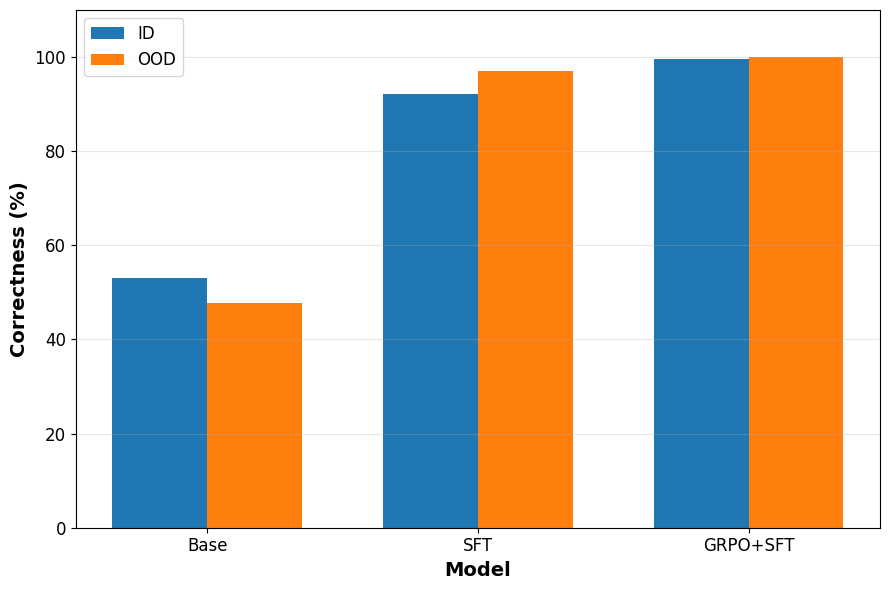

In [ ]:
id_vals, ood_vals = get_metric_by_split("correctness_pct")

x = np.arange(len(MODEL_ORDER))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(x - width/2, id_vals, width, label="ID")
ax.bar(x + width/2, ood_vals, width, label="OOD")

ax.set_xlabel("Model", fontsize=14, fontweight="bold")
ax.set_ylabel("Correctness (%)", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, fontsize=12)
ax.tick_params(axis="y", labelsize=12)
ax.set_ylim(0, 110)
ax.legend(fontsize=12)
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
save_figure(fig, "figure1_correctness_grouped_bar")
plt.show()

Figure 2: Formatting Comparison (Grouped Bar Chart)

Saved: /content/drive/MyDrive/Algebra_Model/Figures/figure2_formatting_grouped_bar.png
Saved: /content/drive/MyDrive/Algebra_Model/Figures/figure2_formatting_grouped_bar.pdf


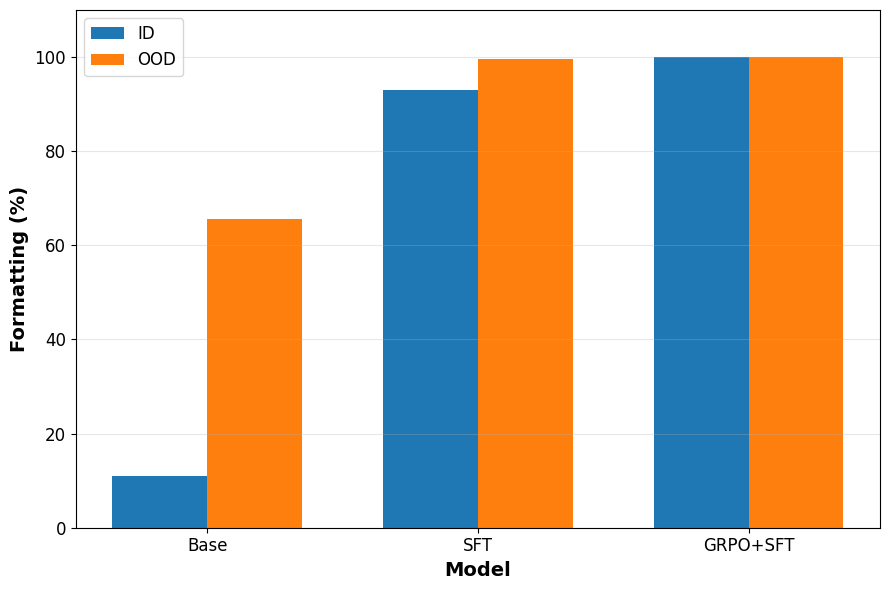

In [ ]:
id_vals, ood_vals = get_metric_by_split("formatting_pct")

x = np.arange(len(MODEL_ORDER))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(x - width/2, id_vals, width, label="ID")
ax.bar(x + width/2, ood_vals, width, label="OOD")

ax.set_xlabel("Model", fontsize=14, fontweight="bold")
ax.set_ylabel("Formatting (%)", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, fontsize=12)
ax.tick_params(axis="y", labelsize=12)
ax.set_ylim(0, 110)
ax.legend(fontsize=12)
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
save_figure(fig, "figure2_formatting_grouped_bar")
plt.show()

Figure 3: Step Count Distribution (Box Plots)

/tmp/ipykernel_3251/4139108360.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=MODEL_ORDER)
/tmp/ipykernel_3251/4139108360.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=MODEL_ORDER)


Saved: /content/drive/MyDrive/Algebra_Model/Figures/figure3_stepcount_boxplots.png
Saved: /content/drive/MyDrive/Algebra_Model/Figures/figure3_stepcount_boxplots.pdf


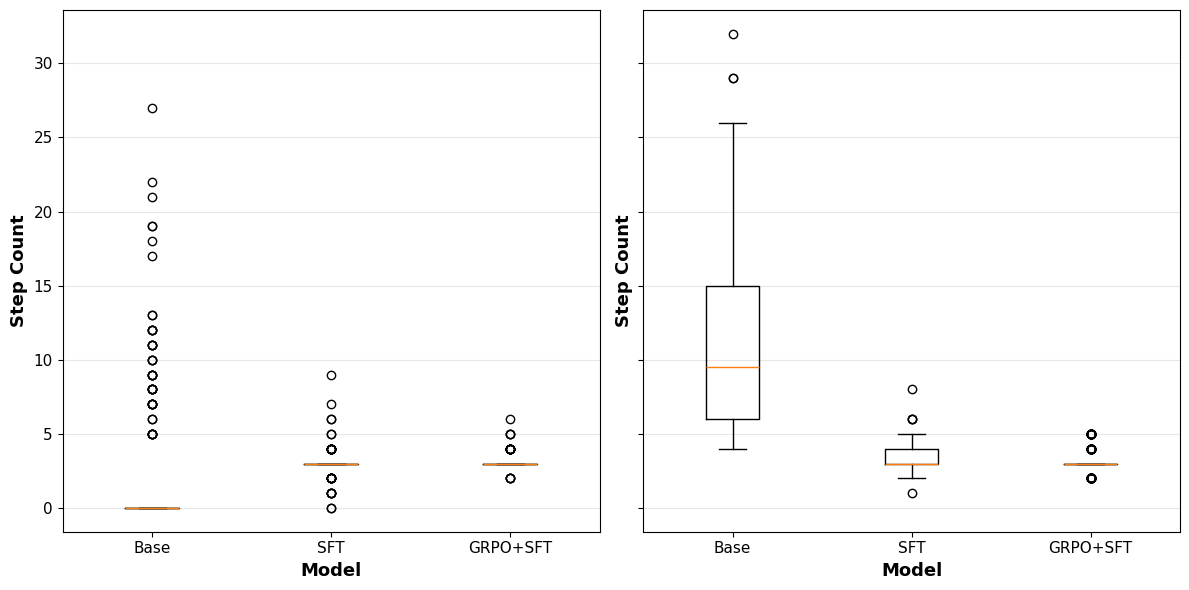

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

for ax, split in zip(axes, SPLIT_ORDER):
    split_df = df[df["split"] == split]
    data = [
        split_df.loc[split_df["model"] == model, "step_count"].dropna().values
        for model in MODEL_ORDER
    ]

    ax.boxplot(data, labels=MODEL_ORDER)
    ax.set_xlabel("Model", fontsize=13, fontweight="bold")
    ax.set_ylabel("Step Count", fontsize=13, fontweight="bold")
    ax.tick_params(axis="x", labelsize=11)
    ax.tick_params(axis="y", labelsize=11)
    ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
save_figure(fig, "figure3_stepcount_boxplots")
plt.show()

Figure 4: Improvement Chart (Delta Accuracy Gains)

Saved: /content/drive/MyDrive/Algebra_Model/Figures/figure4_accuracy_gain_bar.png
Saved: /content/drive/MyDrive/Algebra_Model/Figures/figure4_accuracy_gain_bar.pdf


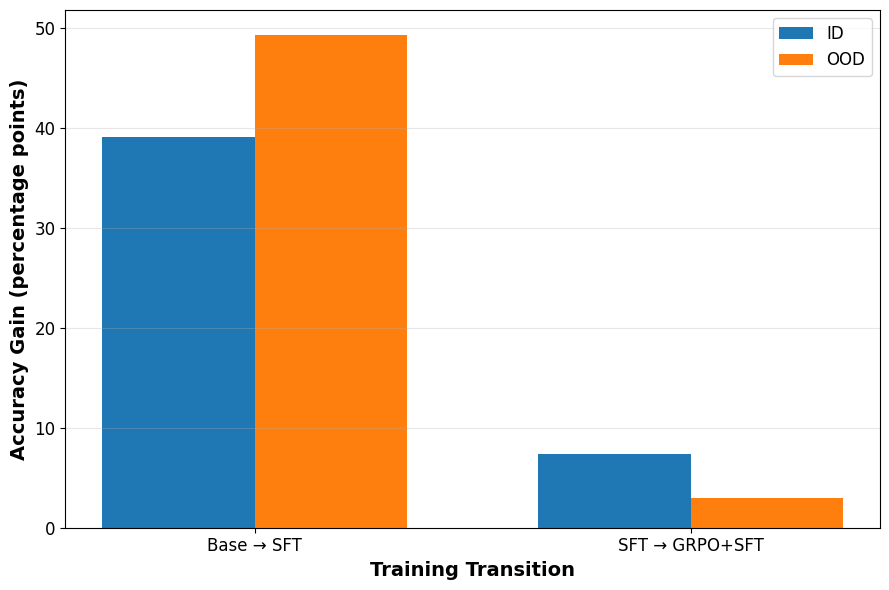

In [ ]:
acc = {
    split: {
        model: summary.loc[
            (summary["split"] == split) & (summary["model"] == model),
            "correctness_pct"
        ].iloc[0]
        for model in MODEL_ORDER
    }
    for split in SPLIT_ORDER
}

delta_labels = ["Base → SFT", "SFT → GRPO+SFT"]
id_deltas = [
    acc["ID"]["SFT"] - acc["ID"]["Base"],
    acc["ID"]["GRPO+SFT"] - acc["ID"]["SFT"]
]
ood_deltas = [
    acc["OOD"]["SFT"] - acc["OOD"]["Base"],
    acc["OOD"]["GRPO+SFT"] - acc["OOD"]["SFT"]
]

x = np.arange(len(delta_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(x - width/2, id_deltas, width, label="ID")
ax.bar(x + width/2, ood_deltas, width, label="OOD")

ax.set_xlabel("Training Transition", fontsize=14, fontweight="bold")
ax.set_ylabel("Accuracy Gain (percentage points)", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(delta_labels, fontsize=12)
ax.tick_params(axis="y", labelsize=12)
ax.legend(fontsize=12)
ax.grid(axis="y", alpha=0.3)

fig.tight_layout()
save_figure(fig, "figure4_accuracy_gain_bar")
plt.show()